In [ ]:
# 모델 학습 전, 데이터의 분포, 크기, 시각적 특성을 파악해 전처리 기준을 잡는 EDA 코드

# EDA는 수집된 데이터를 그래프나 통계적 기법으로 시각화하여
# 패턴 발견, 이상치 탐지, 변수 간 관게 파악 등 데이터의 구조와 특징을
# 직관적으로 이해하기 위해 작성하는 분석 코드이다.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from collections import defaultdict

In [ ]:
# 경로 설정
BASE_PATH = "/content/drive/MyDrive/AI_Project/BrainScan_XAI/archive"
SPLITS = ["Training", "Testing"]
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

/tmp/ipykernel_2008/898010057.py:18: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2008/898010057.py:18: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2008/898010057.py:18: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2008/898010057.py:18: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2008/898010057.py:18: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2008/898010057.py:18: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2008/898010057.py:18: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tm

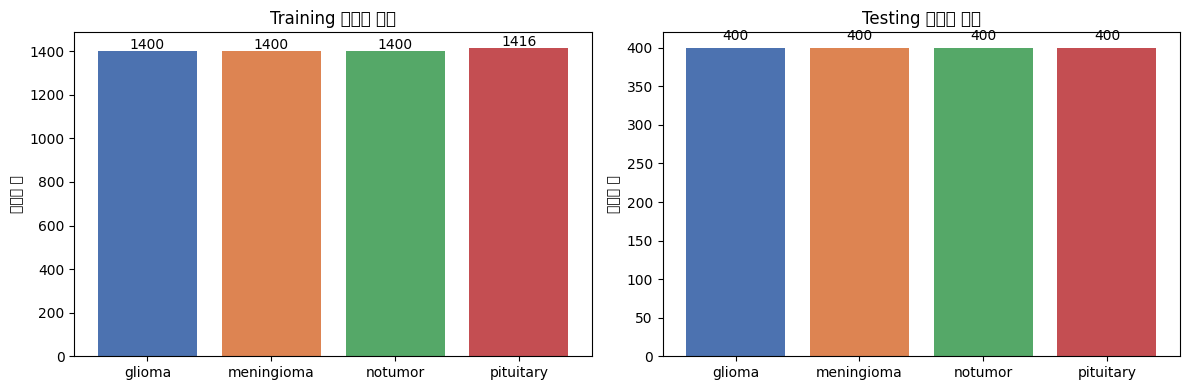

클래스 분포: {'Training': {'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1416}, 'Testing': {'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}}


In [ ]:
# 1. 클래스 분포
# 각 클래스별 이미지 수 확인 -> 불균형 여부 파악
counts = {}
for split in SPLITS : # 데이터셋 분할(train/test) 순회
    counts[split] = {}
    for cls in CLASSES : # 각 분할 내 클래스(종양 유형) 순회
        path = os.path.join(BASE_PATH, split, cls)
        counts[split][cls] = len(os.listdir(path))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, split in zip(axes, SPLITS) : # subplot 축과 분할명을 쌍으로 묶어 순회
    ax.bar(CLASSES, counts[split].values(),
        color=["#4C72B0","#DD8452","#55A868","#C44E52"])
    ax.set_title(f"{split} 클래스 분포")
    ax.set_ylabel("이미지 수")
    for i, v in enumerate(counts[split].values()) : # 막대 인덱스와 값을 함께 순회 (텍스트 라벨용)
        ax.text(i, v + 10, str(v), ha='center')
plt.tight_layout()
plt.show()
print("클래스 분포:", counts)

In [ ]:
# ── 2. 이미지 크기 분포 ─────────────────────────────────────
# 클래스당 100장 샘플링해서 W/H 범위 확인 → Resize 기준값 결정에 사용
sizes = defaultdict(list)
for cls in CLASSES:
    path = os.path.join(BASE_PATH, "Training", cls)
    for fname in os.listdir(path)[:100]:
        img = Image.open(os.path.join(path, fname))
        sizes[cls].append(img.size)  # (width, height)

print("\n[ 이미지 크기 범위 ]")
for cls in CLASSES:
    widths  = [s[0] for s in sizes[cls]]
    heights = [s[1] for s in sizes[cls]]
    print(f"{cls}: W {min(widths)}~{max(widths)}, H {min(heights)}~{max(heights)}")


[ 이미지 크기 범위 ]
glioma: W 512~512, H 512~512
meningioma: W 200~512, H 223~512
notumor: W 173~1024, H 201~1024
pituitary: W 202~1168, H 202~1178


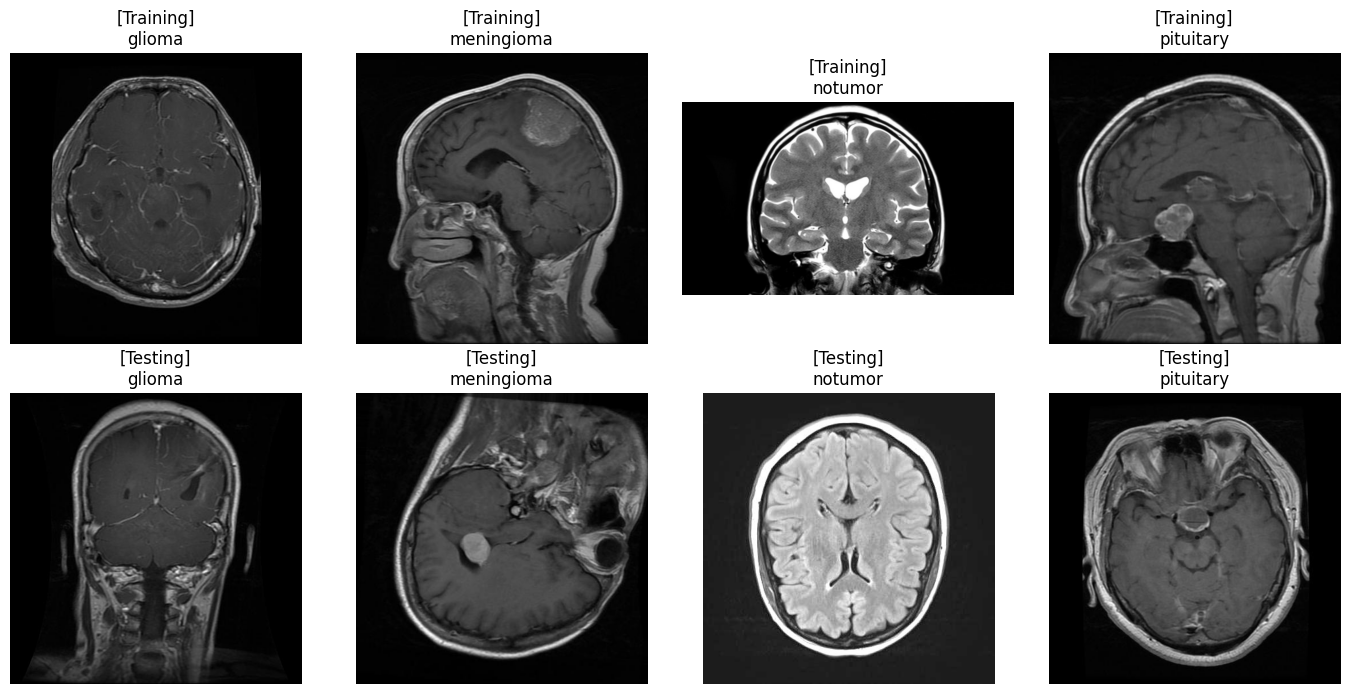

In [ ]:
# 3. 클래스별 샘플 이미지
# Train/Test 각 클래스에서 이미지 1장씩 시각화 -> 육안으로 데이터 품질 확인
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, split in enumerate(SPLITS) : # 행 인덱스와 분할명(train/test)을 함께 순회
    for col, cls in enumerate(CLASSES) : # 열 인덱스와 클래스명을 함께 순회 -> 2D 그리드 위치 결정
        path = os.path.join(BASE_PATH, split, cls)
        fname = os.listdir(path)[0] # 폴더 첫 번째 파일 1장만 선택
        img = Image.open(os.path.join(path, fname)).convert("RGB")
        axes[row][col].imshow(img)
        axes[row][col].set_title(f"[{split}]\n{cls}")
        axes[row][col].axis("off")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2008/3740451769.py:13: UserWarning: Glyph 54589 (\N{HANGUL SYLLABLE PIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2008/3740451769.py:13: UserWarning: Glyph 49472 (\N{HANGUL SYLLABLE SEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2008/3740451769.py:13: UserWarning: Glyph 48157 (\N{HANGUL SYLLABLE BALG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2008/3740451769.py:13: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2008/3740451769.py:13: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2008/3740451769.py:13: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2008/3740451769.py:13: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_

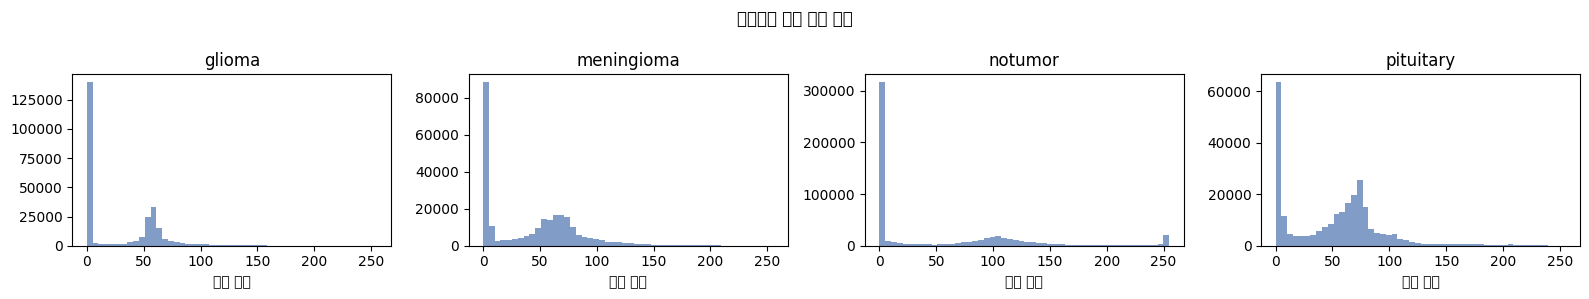

In [ ]:
# 4. 픽셀 밝기 분포
# 클래스별 픽셀값 히스토그램 -> Normalize 평균/표준편차 기준 잡기 위해
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, cls in zip(axes, CLASSES) :  # subplot 축과 클래스명을 쌍으로 묶어 순회 (1:1 대응)
    path = os.path.join(BASE_PATH, "Training", cls)
    fname = os.listdir(path)[0]
    # grayscale("L")로 변환해 밝기값(0~225)만 추출
    img = np.array(Image.open(os.path.join(path, fname)).convert("L"))
    ax.hist(img.flatten(), bins=50, color="#4C72B0", alpha=0.7) # 2D 픽셀 배열을 1D로 펼쳐 히스토그램 입력
    ax.set_title(f"{cls}")
    ax.set_xlabel("픽셀 밝기")
plt.suptitle("클래스별 픽셀 밝기 분포")
plt.tight_layout()
plt.show()

In [ ]:
"""
결과 분석

1. 클래스 분포 ✅

거의 완벽한 균형 (pituitary만 1416으로 16장 차이)
클래스 불균형 처리 불필요

2. 이미지 크기 ⚠️ 핵심
- glioma:     512 × 512  (고정)
- meningioma: 200~512    (제각각)
- notumor:    173~1024   (가장 들쑥날쑥)
- pituitary:  202~1178   (가장 큰 것도 있음)

비유하면 A4, B5, 명함, 포스터가 섞인 상태 — 전부 224×224로 Resize 필수

3. 샘플 이미지 ✅

촬영 방향이 섞여 있음 (정면/측면/단면)
데이터 품질 이상 없음

4. 픽셀 밝기 분포 ✅

전 클래스 공통으로 0(검정) 픽셀이 압도적 → MRI 배경이 검은색이라 당연
Normalize 필요 확인
"""

In [ ]:
"""

EDA 결론 → 전처리 기준 확정:

- Resize:    224 × 224
- Normalize: mean=[0.485, 0.456, 0.406]
             std =[0.229, 0.224, 0.225]  ← ImageNet 기준
- Augmentation: RandomHorizontalFlip, RandomRotation

"""